<h2 style="color:purple" align= "center">Zudio sale performace analysis</h2>

<h2 style="color:green" align= "left">Introduction</h2>

## 
The world of fashion retail data might seem as unpredictable as the latest trends, yet there is always order hidden in the chaos. In this notebook, we will explore Zudio's sales data through various lenses, aiming to extract meaningful insights and even predict revenue based on key variables. Our journey blends solid data science techniques with a touch of dry humor, because even in the most rigorous analysis, we could use a little wit.

## Phases

1. **Phase 1** — Environment Setup & Data Loading
2. **Phase 2** — Data Quality Assessment
3. **Phase 3** — Feaure Engineering
4. **Phase 4** — Businees Review Merics

## Phase 1
# 
1.1 Environment setup importing required libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import kagglehub
import warnings

warnings.filterwarnings('ignore')
print("All libraries imported successfully")

All libraries imported successfully


### 1.2 Load the data

In [25]:
data= pd.read_csv(r"Zudio_sales_data.csv")


### 1.3 intial data inspection

In [26]:
print("First 5 rows:")
print(data.head())
print("=" * 80)

print("Data Info:")
print(data.info())
print("=" * 80)

print("Descriptive Statistics:")
print(data.describe(include='object'))
print("=" * 80)

print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")


First 5 rows:
   Store Country          State      City Category Clothing Type  \
0  Zudio   India      Karnataka     Jalna    Women       Dresses   
1  Zudio   India        Gujarat     Patna     Kids        Skirts   
2  Zudio   India  Uttar Pradesh   Kolkata      Men       Hoodies   
3  Zudio   India    West Bengal   Kolkata    Women       Dresses   
4  Zudio   India    West Bengal  Guwahati      Men       Dresses   

   Store Number  Postal Code Store Type Store Open Date  ...  \
0            30       411084      Owned      2022-06-04  ...   
1            48       404562      Owned      2020-12-19  ...   
2            97       437773     Rented      2023-09-04  ...   
3            93       431725      Owned      2024-04-11  ...   
4            51       415370      Owned      2022-05-29  ...   

   Security Features Order ID  Order Date     Month Customer ID  \
0              Alarm    88240  2024-11-06  November      233084   
1              Alarm    78145  2024-06-17      June      9

## Phase 2: Data Quality Assessment

###  2.1: Check Data Structure

#
Removing Unnecessary columns to reduce the complexity

In [27]:
data=data.drop(columns=['Store','Country','Postal Code','Manager ID','Store Address','Contact Information','Staff Count','Customer ID','Product ID','Store Type','Security Features'])

In [32]:
#Checking data types 
print("checking data types:")
print(data.dtypes)
print('=' * 100)

data['Store Open Date']=pd.to_datetime(data['Store Open Date'])
data['Order Date']=pd.to_datetime(data['Order Date'])

print(f"Date Range: {data['Store Open Date'].min()} to {data['Store Open Date'].max()}")
print(f"Period: {(data['Store Open Date'].max() - data['Store Open Date'].min()).days} days")
print("=" * 80)

print(f"Unique Customers: {data['Customer Name'].nunique():,}")
print(f"Unique products: {data['Clothing Type'].nunique():,}")
print(f"Unique cities: {data['City'].nunique():,}")

checking data types:
State                                object
City                                 object
Category                             object
Clothing Type                        object
Store Number                          int64
Store Open Date              datetime64[ns]
Selling Area Size (sq ft)             int64
Store Manager                        object
Operating Hours                      object
Parking Availability                 object
Order ID                              int64
Order Date                   datetime64[ns]
Month                                object
Customer Name                        object
Price                                 int64
Quantity                              int64
Sales Profit                        float64
start_time                           object
end_time                             object
dtype: object
Date Range: 2020-01-01 00:00:00 to 2024-12-03 00:00:00
Period: 1798 days
Unique Customers: 7,499
Unique products: 11
Unique citie

## 
2.2 missing values analysis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      7899 non-null   object        
 1   City                       7899 non-null   object        
 2   Category                   7899 non-null   object        
 3   Clothing Type              7899 non-null   object        
 4   Store Number               7899 non-null   int64         
 5   Store Open Date            7899 non-null   datetime64[ns]
 6   Selling Area Size (sq ft)  7899 non-null   int64         
 7   Store Manager              7899 non-null   object        
 8   Operating Hours            7899 non-null   object        
 9   Parking Availability       7899 non-null   object        
 10  Order ID                   7899 non-null   int64         
 11  Order Date                 7899 non-null   object        
 12  Month 

There are no missing values in the data set

2.3 Duplicates check

In [ ]:
dup= data.duplicated().sum()
print(f"duplicate rows:",{dup})

duplicate rows: {np.int64(0)}


Data does not contain any duplicate values

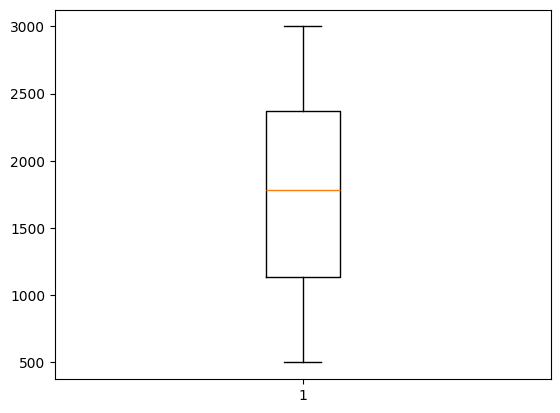

In [ ]:
plt.boxplot(data['Price'])
plt.show()

## Phase 3:Feature Engineering

In [33]:
data['Total_Amount']=data['Price']*data['Quantity']
data['Order Date']=pd.to_datetime(data['Order Date'])
data['year']=data['Order Date'].dt.year
data['month']=data['Order Date'].dt.month
data['day']=data['Order Date'].dt.day
data['dayofweek']=data['Order Date'].dt.dayofweek



## Phase 4: Exploratory Data Analysis (EDA)

### Step 4.1: Business Overview Metrics

In [ ]:
print("=" * 80)
print("BUSINESS OVERVIEW METRICS")
print("=" * 80)

total_revenue = data['Total_Amount'].sum()
total_line_items = len(data)
total_orders = data['Order ID'].nunique()
unique_customers = data['Customer Name'].nunique()
unique_products = data['Clothing Type'].nunique()
unique_cities = data['City'].nunique()

print(f"\nTotal Revenue: £{total_revenue:,.2f}")
print(f"Total Line Items (rows): {total_line_items:,}")
print(f"Total Orders (unique InvoiceNo): {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Unique Countries: {unique_cities:,}")

print(f"\nKey Averages:")
print(f"   - Avg Order Value: {total_revenue/total_orders:,.2f}")
print(f"   - Avg Customer Spend: {total_revenue/unique_customers:,.2f}")
print(f"   - Orders per Customer: {total_orders/unique_customers:.2f}")

print(f"\nBasic metrics calculated")

BUSINESS OVERVIEW METRICS

Total Revenue: £62,612,833.00
Total Line Items (rows): 7,899
Total Orders (unique InvoiceNo): 7,559
Unique Customers: 7,499
Unique Products: 11
Unique Countries: 42

Key Averages:
   - Avg Order Value: 8,283.22
   - Avg Customer Spend: 8,349.49
   - Orders per Customer: 1.01

Basic metrics calculated


### Step 4.2: Time Based Analysis

In [34]:
revenue_by_month=data.groupby(data['Order Date'].dt.to_period('M')).agg(
    Revenue=('Total_Amount', 'sum'),
    Orders=('Order ID', 'nunique'),
    LineItems=('Order ID', 'count'))
revenue_by_month['AOV'] = revenue_by_month['Revenue'] / revenue_by_month['Orders']

print("\nRevenue by Month (Top 5):")
print(revenue_by_month.sort_values('Revenue', ascending=False).head())
print("=" * 80)

# Transactions by day of week (0=Monday, 6=Sunday)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tx_by_dow = data.groupby('dayofweek').agg({'Total_Amount': 'sum', 'Order ID': 'count'})
tx_by_dow.index = [days[i] for i in tx_by_dow.index]
tx_by_dow.columns = ['Revenue', 'Transactions']

print("Transactions by Day of Week:")
print(tx_by_dow)
print("=" * 80)
 





Revenue by Month (Top 5):
            Revenue  Orders  LineItems          AOV
Order Date                                         
2024-10     5930474     739        743  8024.998647
2024-08     5796433     721        724  8039.435506
2024-11     5782246     728        729  7942.645604
2024-01     5761931     706        706  8161.375354
2024-04     5661436     718        719  7885.008357
Transactions by Day of Week:
           Revenue  Transactions
Monday     8854731          1121
Tuesday    9247435          1148
Wednesday  8588068          1114
Thursday   9211307          1105
Friday     9214183          1126
Saturday   8403498          1102
Sunday     9093611          1183


4.2.1 Visualisaion for time based analysis

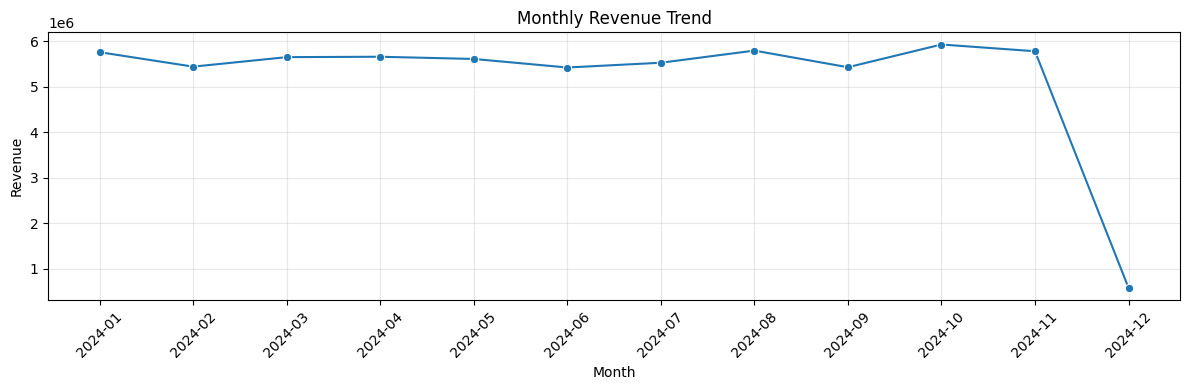

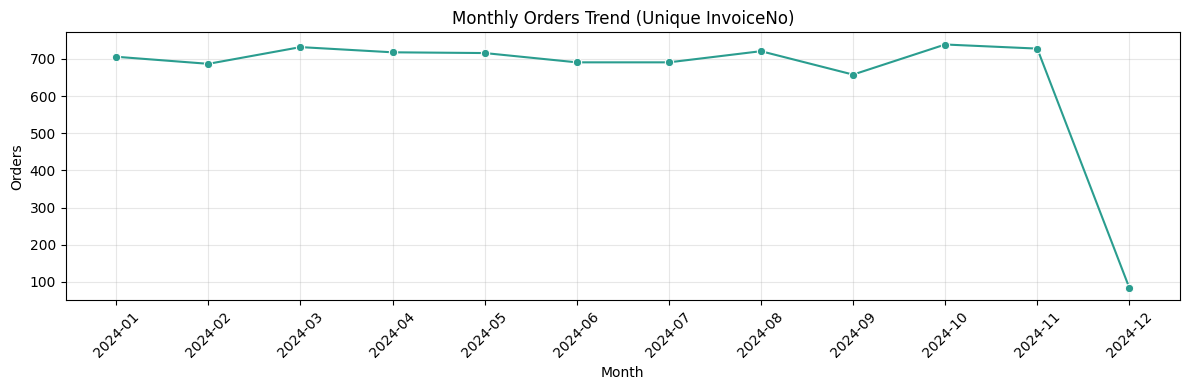

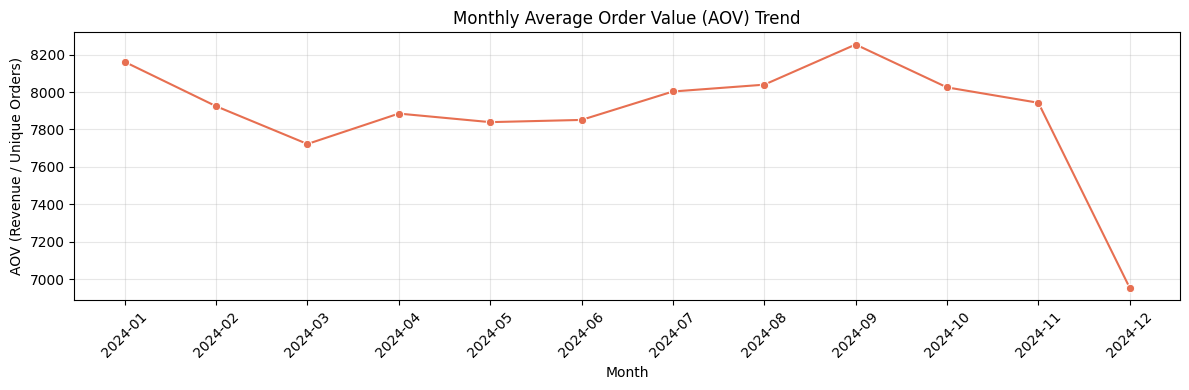

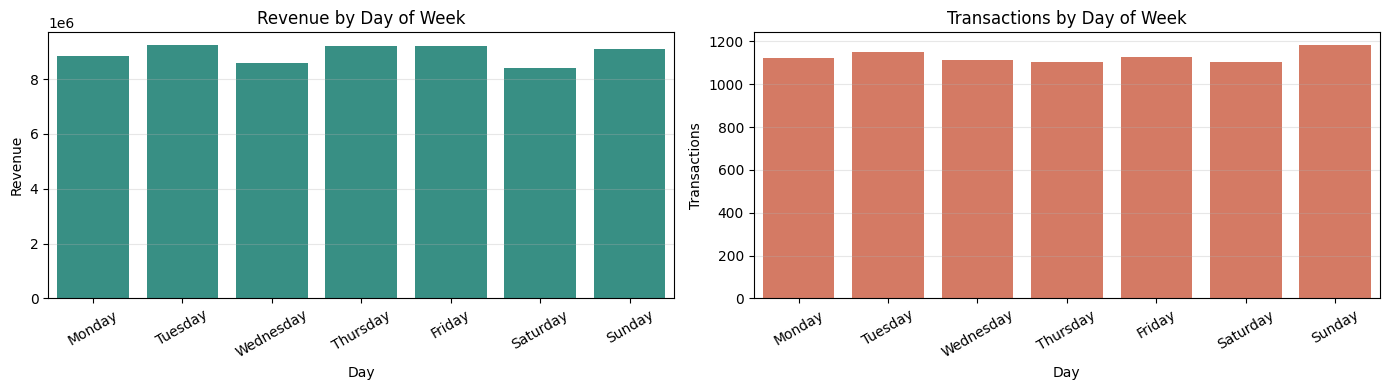

In [36]:
monthly_plot = revenue_by_month.copy()
monthly_plot.index = monthly_plot.index.astype(str)

plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_plot.index, y=monthly_plot['Revenue'], marker='o', color='#1f77b4')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_plot.index, y=monthly_plot['Orders'], marker='o', color='#2a9d8f')
plt.title('Monthly Orders Trend (Unique InvoiceNo)')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_plot.index, y=monthly_plot['AOV'], marker='o', color='#e76f51')
plt.title('Monthly Average Order Value (AOV) Trend')
plt.xlabel('Month')
plt.ylabel('AOV (Revenue / Unique Orders)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=tx_by_dow.index, y=tx_by_dow['Revenue'].values, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(x=tx_by_dow.index, y=tx_by_dow['Transactions'].values, ax=axes[1], color='#e76f51')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()



### Step 4.3: Product Analysis


Top 10 Products by Revenue:
               Revenue  QuantitySold  Transactions
Clothing Type                                     
Dresses        5933781          3375           748
Skirts         5801758          3305           726
Pants          5791253          3241           721
Sweaters       5787607          3223           700
Jackets        5761989          3275           735
Shirts         5736544          3187           706
Hoodies        5724538          3294           704
T-shirts       5695386          3288           735
Tops           5524012          3240           722
Jeans          5500614          3142           702


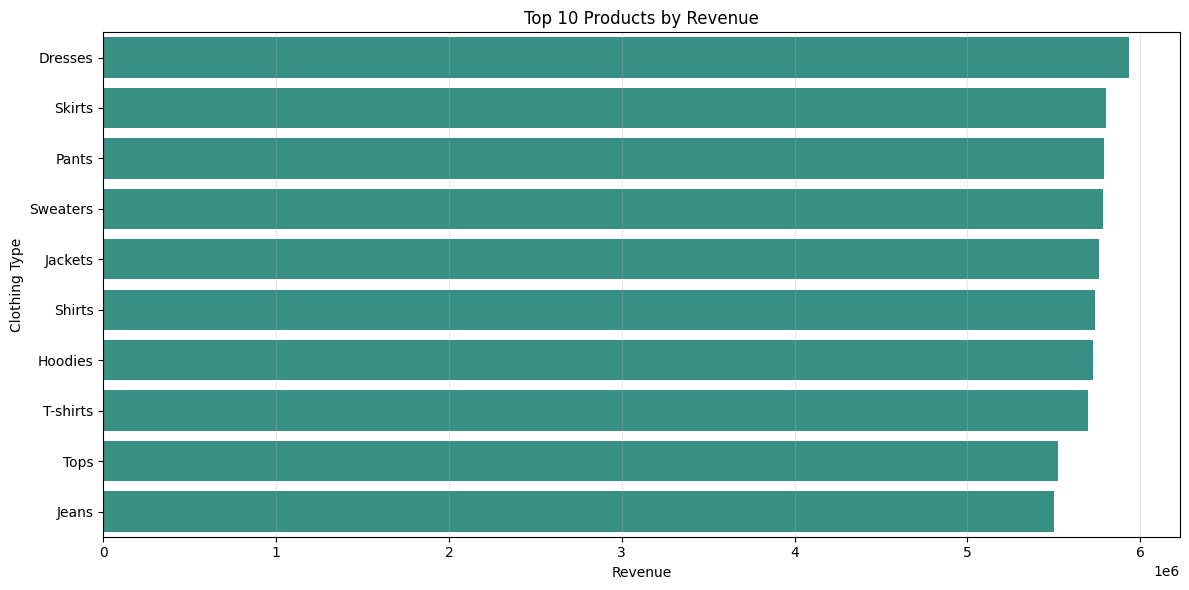


Product analysis complete


In [42]:
product_revenue = data.groupby('Clothing Type').agg({
    'Total_Amount': 'sum',
    'Quantity': 'sum',
    'Order ID': 'count',
    'Clothing Type': 'first'
}).sort_values('Total_Amount', ascending=False)
product_revenue.columns = ['Revenue', 'QuantitySold', 'Transactions', 'Clothing Type']

print("\nTop 10 Products by Revenue:")
print(product_revenue[['Revenue', 'QuantitySold', 'Transactions']].head(10))

top_products_plot = product_revenue[['Revenue', 'Clothing Type']].head(10).copy()
top_products_plot['Label'] = (
    top_products_plot['Clothing Type'].astype(str).str.slice(0, 45)
 )
top_products_plot = top_products_plot.sort_values('Revenue', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_plot, x='Revenue', y='Label', color='#2a9d8f')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Clothing Type')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nProduct analysis complete")
